## Import Library

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

## Data Cleaning

In [165]:
def clean_columns(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
    return df

def clean_string_values(df):
    df = df.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip().str.lower()
    return df

## Load Data

In [166]:
data = pd.read_csv("all_data_siswa_v2.csv")
data = clean_columns(data)
data = clean_string_values(data)

rules_ikl_it = pd.read_csv("rules_ikl_it.csv")
rules_ikl_it = clean_columns(rules_ikl_it)
rules_ikl_it = clean_string_values(rules_ikl_it)

rules_is = pd.read_csv("rules_is.csv")
rules_is = clean_columns(rules_is)
rules_is = clean_string_values(rules_is)

rules_ih = pd.read_csv("rules_ih.csv")
rules_ih = clean_columns(rules_ih)
rules_ih = clean_string_values(rules_ih)

print("Data siswa:", data.shape)
display(data.head())
print("Rules IKL/IT:", rules_ikl_it.shape)
display(rules_ikl_it.head())
print("Rules IS:", rules_is.shape)
display(rules_is.head())
print("Rules IH:", rules_ih.shape)
display(rules_ih.head())

Data siswa: (261, 16)


,no,nama_lengkap,kelas,bahasa_indonesia,matematika,ipa,ips,bahasa_inggris,iq,ikl,it,is,ih,jurusan_sebenarnya,minat,hasil_pm
0,1,abdillah ananda rifai,x1,87,88,89,90,95,131,0.500,1.000,0.500,0.500,ilmu terapan,ilmu terapan,ilmu kesehatan dan lingkungan
1,2,adinda dwi putri kartika,x1,85,75,79,88,78,99,0.500,0.500,0.500,1.000,ilmu humaniora,ilmu humaniora,ilmu sosial
2,3,aruna rizkan jadi,x1,78,75,73,76,72,96,0.500,0.500,1.000,0.500,ilmu sosial,ilmu sosial,ilmu sosial
3,4,bagus raehan arighi,x1,87,86,83,87,76,122,0.500,1.000,0.500,0.500,ilmu terapan,ilmu terapan,ilmu sosial
4,5,desak komang aprilia kristanti,x1,84,85,83,85,87,94,1.000,0.500,0.500,0.500,ilmu kesehatan dan lingkungan,ilmu kesehatan dan lingkungan,ilmu humaniora


Rules IKL/IT: (72, 6)


,rule,r_matematika,r_ipa,r_iq,r_minat,r_output
0,r1,rendah,rendah,bawah_rata_rata,tidak,kurang sesuai
1,r2,rendah,rendah,rata_rata,tidak,kurang sesuai
2,r3,rendah,rendah,atas_rata_rata,tidak,kurang sesuai
3,r4,rendah,rendah,superior,tidak,kurang sesuai
4,r5,rendah,sedang,bawah_rata_rata,tidak,kurang sesuai


Rules IS: (24, 5)


,rule,r_ips,r_iq,r_minat,r_output
0,r1,rendah,bawah_rata_rata,tidak,kurang sesuai
1,r2,rendah,bawah_rata_rata,minat,kurang sesuai
2,r3,rendah,rata_rata,tidak,kurang sesuai
3,r4,rendah,rata_rata,minat,kurang sesuai
4,r5,rendah,atas_rata_rata,tidak,kurang sesuai


Rules IH: (72, 6)


,rule,r_bahasa_indonesia,r_bahasa_inggris,r_iq,r_minat,r_output
0,r1,rendah,rendah,bawah_rata_rata,tidak,kurang sesuai
1,r2,rendah,rendah,rata_rata,tidak,kurang sesuai
2,r3,rendah,rendah,atas_rata_rata,tidak,kurang sesuai
3,r4,rendah,rendah,superior,tidak,kurang sesuai
4,r5,rendah,sedang,bawah_rata_rata,tidak,kurang sesuai


## Fungsi Keanggotaan Fuzzy

In [167]:
def naik(x, a, b):
    x = float(x)
    if x >= b:
        return 1.0
    if x <= a:
        return 0.0
    return (x - a) / (b - a)

def turun(x, a, b):
    x = float(x)
    if x <= a:
        return 1.0
    if x >= b:
        return 0.0
    return (b - x) / (b - a)

def segitiga(x, a, b, tipun=None):
    x = float(x)
    puncak = 0
    if tipun is None:
        puncak = (a + b) / 2
    else:
        puncak = tipun
    if x <= a or x >= b:
        return 0.0
    if x == puncak:
        return 1.0
    if x < puncak:
        return naik(x, a, puncak)
    return turun(x, puncak, b)


## Penentuan Kriteria, Domain Fuzzy, Profil Ideal, dan Bobot Gap

In [168]:
domain_fuzzy = {
    "bahasa_indonesia": {
        "rendah": lambda x: turun(x, 65, 79),
        "sedang": lambda x: segitiga(x, 75, 87, 80),
        "tinggi": lambda x: naik(x, 83, 95),
    },
    "matematika": {
        "rendah": lambda x: turun(x, 65, 80),
        "sedang": lambda x: segitiga(x, 76, 89, 82),
        "tinggi": lambda x: naik(x, 85, 93),
    },
    "ipa": {
        "rendah": lambda x: turun(x, 60, 79),
        "sedang": lambda x: segitiga(x, 75, 85, 80 ),
        "tinggi": lambda x: naik(x, 81, 91),
    },
    "ips": {
        "rendah": lambda x: turun(x, 73, 86),
        "sedang": lambda x: segitiga(x, 82, 89, 86),
        "tinggi": lambda x: naik(x, 85, 90),
    },
    
    "bahasa_inggris": {
        "rendah": lambda x: turun(x, 50, 77),
        "sedang": lambda x: segitiga(x, 73, 84, 79),
        "tinggi": lambda x: naik(x, 80, 95),
    },
    "iq": {
        "bawah_rata_rata": lambda x: turun(x, 70, 95),
        "rata_rata": lambda x: segitiga(x, 85, 115),
        "atas_rata_rata": lambda x: segitiga(x, 105, 125),
        "superior": lambda x: naik(x, 115, 139),
    },
}

PROFIL_IDEAL = {
    "IKL": 3.0,
    "IT": 2.8,
    "IS": 2.6,
    "IH": 2.4,
}

kelayakan = {
    "kurang_sesuai": 1,
    "sesuai": 2,
    "sangat_sesuai": 3,
}

gap_table = [
    {"gap": -2.0, "bobot": 0},
    {"gap": -1.8, "bobot": 1},
    {"gap": -1.6, "bobot": 2},
    {"gap": -1.4, "bobot": 3},
    {"gap": -1.2, "bobot": 4},
    {"gap": -1.0, "bobot": 5},
    {"gap": -0.8, "bobot": 6},
    {"gap": -0.6, "bobot": 7},
    {"gap": -0.4, "bobot": 8},
    {"gap": -0.2, "bobot": 9},
    {"gap":  0.0, "bobot": 10},
    {"gap":  0.2, "bobot": 9.5},
    {"gap":  0.4, "bobot": 8.5},
    {"gap":  0.6, "bobot": 7.5},
    {"gap":  0.8, "bobot": 6.5},
    {"gap":  1.0, "bobot": 5.5},
    {"gap":  1.2, "bobot": 4.5},
    {"gap":  1.4, "bobot": 3.5},
    {"gap":  1.6, "bobot": 2.5},
    {"gap":  1.8, "bobot": 1.5},
    {"gap":  2.0, "bobot": 0.5},
]

JURUSAN_LABEL = {
    "IKL": "Ilmu Kesehatan dan Lingkungan",
    "IT": "Ilmu Terapan",
    "IS": "Ilmu Sosial",
    "IH": "Ilmu Humaniora",
}

JURUSAN_MAP = {
    "ilmu kesehatan dan lingkungan": "IKL",
    "ilmu kesehatan lingkungan": "IKL",
    "ikl": "IKL",
    "ilmu terapan": "IT",
    "it": "IT",
    "ilmu sosial": "IS",
    "is": "IS",
    "ilmu humaniora": "IH",
    "ih": "IH",
}

JURUSAN_CONFIG = {
    "IKL": (
        rules_ikl_it,
        {"matematika": "r_matematika", "ipa": "r_ipa", "iq": "r_iq"},
        "ikl",
    ),
    "IT": (
        rules_ikl_it,
        {"matematika": "r_matematika", "ipa": "r_ipa", "iq": "r_iq"},
        "it",
    ),
    "IS": (
        rules_is,
        {"ips": "r_ips", "iq": "r_iq"},
        "is",
    ),
    "IH": (
        rules_ih,
        {
            "bahasa_indonesia": "r_bahasa_indonesia",
            "bahasa_inggris": "r_bahasa_inggris",
            "iq": "r_iq",
        },
        "ih",
    ),
}


## Visualisasi Kurva Fungsi Keanggotaan

In [169]:
def plot_fuzzy(variable_name, funcs, x_range):
    x = np.linspace(x_range[0], x_range[1], 200)

    plt.figure(figsize=(8,4))

    for label, func in funcs.items():
        y = [func(val) for val in x]
        plt.plot(x, y, label=label)

    plt.title(f"Fungsi Keanggotaan - {variable_name}")
    plt.xlabel("Nilai")
    plt.ylabel("Derajat Keanggotaan")
    plt.legend()
    plt.grid()
    plt.show()

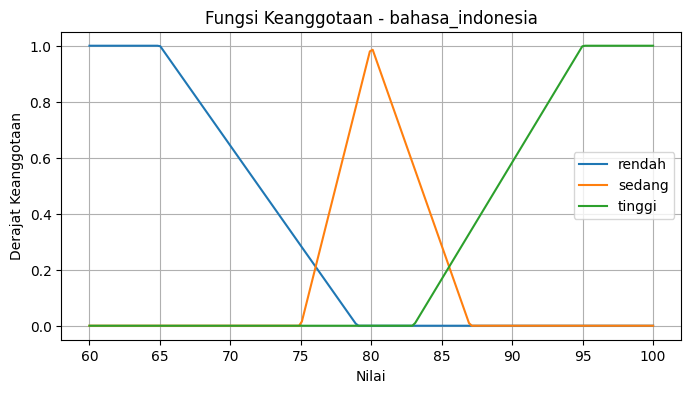

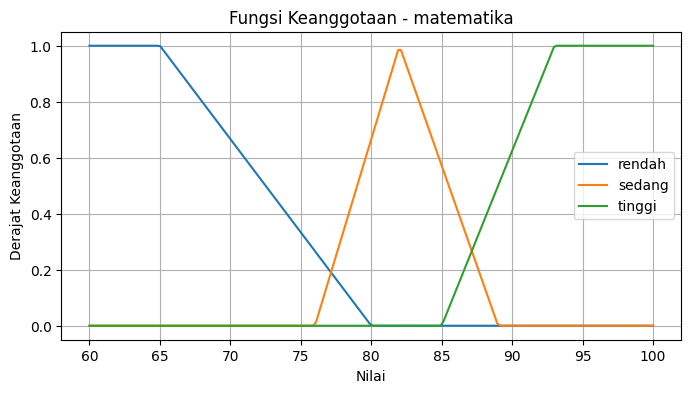

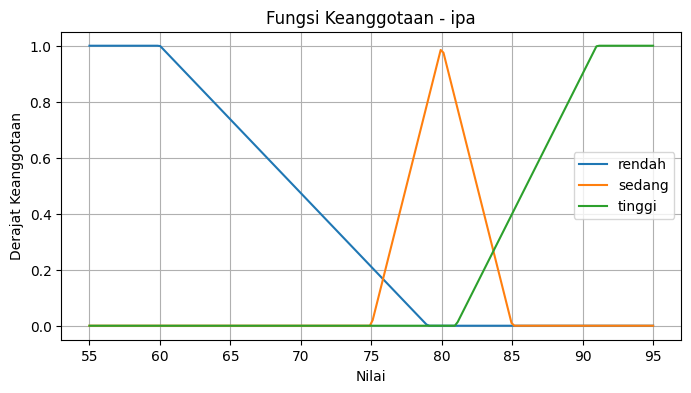

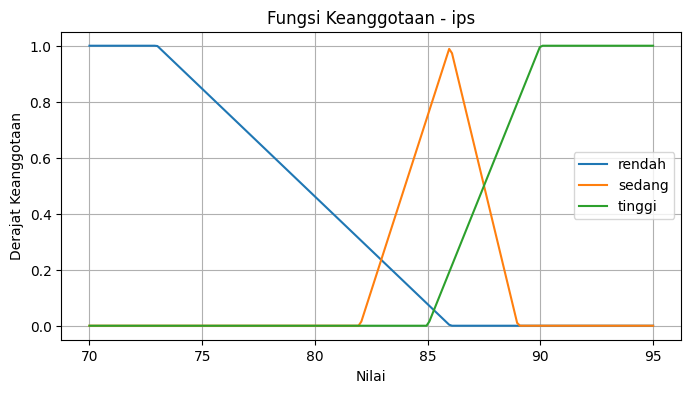

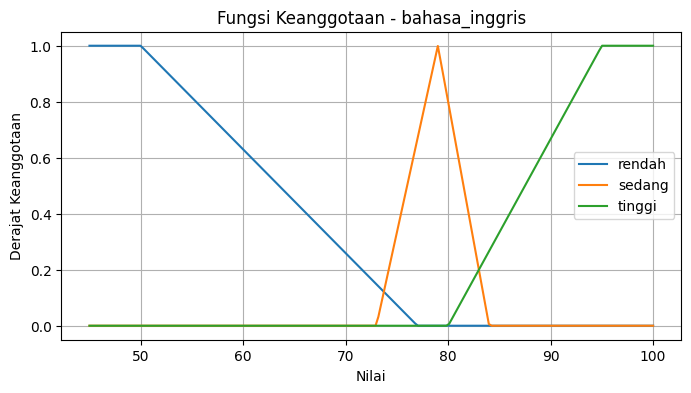

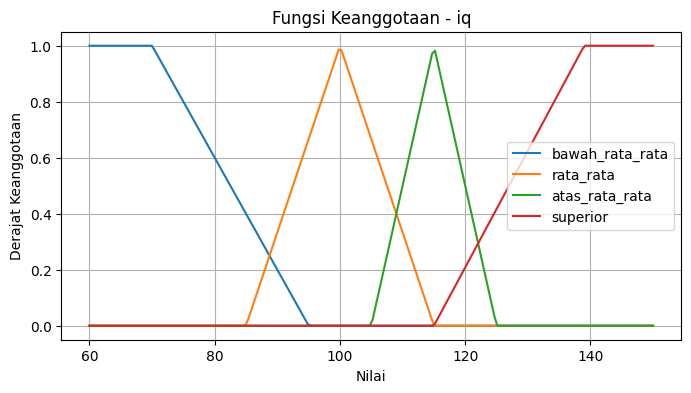

In [170]:
ranges = {
    "matematika": (60, 100),
    "ipa": (55, 95),
    "ips": (70, 95),
    "bahasa_indonesia": (60, 100),
    "bahasa_inggris": (45, 100),
    "iq": (60, 150),
}

for var in domain_fuzzy:
    plot_fuzzy(var, domain_fuzzy[var], ranges[var])

## Fuzzifikasi Nilai Input

In [171]:
def fuzzifikasi(row):
    data_fuzzy = {}

    kolom_nilai = [
        "matematika",
        "ipa",
        "ips",
        "bahasa_indonesia",
        "bahasa_inggris",
    ]

    kolom_minat = ["ikl", "it", "is", "ih"]

    for key, value in row.items():
        if key in kolom_minat:
            data_fuzzy[key] = float(value)

        elif key in kolom_nilai:
            data_fuzzy[key] = {
                "rendah": round(domain_fuzzy[key]["rendah"](float(value)), 3),
                "sedang": round(domain_fuzzy[key]["sedang"](float(value)), 3),
                "tinggi": round(domain_fuzzy[key]["tinggi"](float(value)), 3),
            }

        elif key == "iq":
            data_fuzzy[key] = {
                "bawah_rata_rata": round(domain_fuzzy["iq"]["bawah_rata_rata"](float(value)), 3),
                "rata_rata": round(domain_fuzzy["iq"]["rata_rata"](float(value)), 3),
                "atas_rata_rata": round(domain_fuzzy["iq"]["atas_rata_rata"](float(value)), 3),
                "superior": round(domain_fuzzy["iq"]["superior"](float(value)), 3),
            }

        else:
            data_fuzzy[key] = value

    return data_fuzzy

In [172]:
def tampilkan_fuzzifikasi(data_fuzzy):
    rows = []

    for variabel, nilai in data_fuzzy.items():
        if isinstance(nilai, dict):
            for kategori, derajat in nilai.items():
                rows.append({
                    "Variabel": variabel,
                    "Kategori": kategori,
                    "Derajat Keanggotaan": derajat
                })
        else:
            rows.append({
                "Variabel": variabel,
                "Kategori": "-",
                "Derajat Keanggotaan": nilai
            })

    return pd.DataFrame(rows)

In [173]:
index_siswa = 0
item = data.iloc[index_siswa].to_dict()

fuzz = fuzzifikasi(item)

print("Hasil Fuzzifikasi (Detail):")
display(tampilkan_fuzzifikasi(fuzz))

Hasil Fuzzifikasi (Detail):


,Variabel,Kategori,Derajat Keanggotaan
0,no,-,1
1,nama_lengkap,-,abdillah ananda rifai
2,kelas,-,x1
3,bahasa_indonesia,rendah,0.000
4,bahasa_indonesia,sedang,0.000
5,bahasa_indonesia,tinggi,0.333
6,matematika,rendah,0.000
7,matematika,sedang,0.143
8,matematika,tinggi,0.375
9,ipa,rendah,0.000


## Inferensi Fuzzy

In [174]:
def inferensi_fuzzy(data_fuzzy, rules_df, mapping_rule, key_minat, nama_jurusan):
    hasil_rule = []

    for idx, rule in rules_df.iterrows():
        minat_rule = str(rule["r_minat"]).strip().lower()
        output_rule = str(rule["r_output"]).strip().lower().replace(" ", "_")

        if data_fuzzy[key_minat] == 1 and minat_rule == "tidak":
            continue

        if data_fuzzy[key_minat] == 0.5 and minat_rule == "minat":
            continue

        nilai_antecedent = []
        komponen_perhitungan = []

        for key_data, key_rule in mapping_rule.items():
            kondisi = str(rule[key_rule]).strip().lower()
            derajat = data_fuzzy[key_data].get(kondisi, 0)

            nilai_antecedent.append(derajat)
            komponen_perhitungan.append(f"{key_data}:{round(derajat, 3)}")

        nilai_minat = data_fuzzy[key_minat]
        nilai_antecedent.append(nilai_minat)
        komponen_perhitungan.append(f"minat:{round(nilai_minat, 3)}")

        firing_strength = min(nilai_antecedent)

        hasil_rule.append({
            "Jurusan": nama_jurusan,
            "Rule_Index": idx + 1,
            "Output": output_rule,
            "Firing_Strength": round(firing_strength, 3),
            "Perhitungan": f"min({', '.join(komponen_perhitungan)}) = {round(firing_strength, 3)}",
        })

    return hasil_rule

In [175]:
def inferensi_semua_jurusan(data_fuzzy):
    daftar_jurusan = [
        ("IKL", rules_ikl_it, {"matematika": "r_matematika", "ipa": "r_ipa", "iq": "r_iq"}, "ikl"),
        ("IT",  rules_ikl_it, {"matematika": "r_matematika", "ipa": "r_ipa", "iq": "r_iq"}, "it"),
        ("IS",  rules_is,     {"ips": "r_ips", "iq": "r_iq"}, "is"),
        ("IH",  rules_ih,     {"bahasa_indonesia": "r_bahasa_indonesia", "bahasa_inggris": "r_bahasa_inggris", "iq": "r_iq"}, "ih"),
    ]

    hasil_rule = []
    for nama_jurusan, rules_df, mapping_rule, key_minat in daftar_jurusan:
        hasil_rule.extend(
            inferensi_fuzzy(
                data_fuzzy=data_fuzzy,
                rules_df=rules_df,
                mapping_rule=mapping_rule,
                key_minat=key_minat,
                nama_jurusan=nama_jurusan,
            )
        )

    return hasil_rule

In [176]:
def tabel_firing_rules(hasil_per_jurusan, aktif_saja=True, mode="rule", top_n=None):
    rows = []

    for detail in hasil_per_jurusan.values():
        rows.extend(detail["hasil_rule"])

    df = pd.DataFrame(rows)

    if df.empty:
        return df

    if aktif_saja:
        df = df[df["Firing_Strength"] > 0].copy()

    if df.empty:
        return df

    if mode == "strength":
        df = df.sort_values(
            ["Jurusan", "Firing_Strength", "Rule_Index"],
            ascending=[True, False, True]
        )
    else:
        df = df.sort_values(
            ["Jurusan", "Rule_Index"],
            ascending=[True, True]
        )

    df = df.reset_index(drop=True)

    if top_n is not None:
        df = df.head(top_n)

    return df[["Jurusan", "Rule_Index", "Output", "Perhitungan", "Firing_Strength"]]


In [177]:
def tampilkan_rule_aktif(index_siswa=0):
    item = data.iloc[index_siswa].to_dict()
    data_fuzzy = fuzzifikasi(item)

    hasil_rule_semua = inferensi_semua_jurusan(data_fuzzy)
    df_rule = pd.DataFrame(hasil_rule_semua)
    df_rule_aktif = df_rule[df_rule["Firing_Strength"] > 0].copy()

    display(df_rule_aktif[[
        "Jurusan",
        "Rule_Index",
        "Output",
        "Perhitungan",
        "Firing_Strength",
    ]])

    return df_rule_aktif

In [178]:
df_rule_aktif = tampilkan_rule_aktif(0)

,Jurusan,Rule_Index,Output,Perhitungan,Firing_Strength
23,IKL,24,sesuai,"min(matematika:0.143, ipa:0.8, iq:0.667, minat:0.5) = 0.143",0.143
35,IKL,36,sesuai,"min(matematika:0.375, ipa:0.8, iq:0.667, minat:0.5) = 0.375",0.375
59,IT,60,sesuai,"min(matematika:0.143, ipa:0.8, iq:0.667, minat:1.0) = 0.143",0.143
71,IT,72,sangat_sesuai,"min(matematika:0.375, ipa:0.8, iq:0.667, minat:1.0) = 0.375",0.375
83,IS,23,sesuai,"min(ips:1.0, iq:0.667, minat:0.5) = 0.5",0.500
119,IH,36,sesuai,"min(bahasa_indonesia:0.333, bahasa_inggris:1.0, iq:0.667, minat:0.5) = 0.333",0.333


## Agregasi

In [179]:
def agregasi_output_per_jurusan(hasil_rule_semua):
    agregasi = {}

    for rule in hasil_rule_semua:
        jurusan = rule["Jurusan"]
        output = rule["Output"]
        firing_strength = rule["Firing_Strength"]

        if jurusan not in agregasi:
            agregasi[jurusan] = {
                "kurang_sesuai": [],
                "sesuai": [],
                "sangat_sesuai": []
            }

        agregasi[jurusan][output].append(firing_strength)

    agregasi_ringkas = {
        jurusan: {
            "kurang_sesuai": max(outputs["kurang_sesuai"]) if outputs["kurang_sesuai"] else 0,
            "sesuai": max(outputs["sesuai"]) if outputs["sesuai"] else 0,
            "sangat_sesuai": max(outputs["sangat_sesuai"]) if outputs["sangat_sesuai"] else 0,
        }
        for jurusan, outputs in agregasi.items()
    }

    return agregasi, agregasi_ringkas

In [180]:
# for jurusan, outputs in agregasi.items():
#     print(f"\n=== {jurusan} ===")

#     for kategori, values in outputs.items():
#         print(f"{kategori.upper()}:")
#         print(values)
#         print("MAX =", max(values) if values else 0)

In [181]:
df_agregasi = pd.DataFrame([
    {
        "Jurusan": jurusan,
        "Kurang Sesuai": nilai["kurang_sesuai"],
        "Sesuai": nilai["sesuai"],
        "Sangat Sesuai": nilai["sangat_sesuai"],
    }
    for jurusan, nilai in agregasi_ringkas.items()
])

display(df_agregasi)

,Jurusan,Kurang Sesuai,Sesuai,Sangat Sesuai
0,IKL,0.000,0.375,0.000
1,IT,0.000,0.143,0.375
2,IS,0.000,0.500,0.000
3,IH,0.000,0.333,0.000


In [182]:
# # output hasil inferensi in all rules
# for kategori, values in agregasi.items():
#     print(f"\n{kategori.upper()}:")
#     print(values)
#     print("MAX =", max(values) if values else 0)

## Defuzzifikasi

In [183]:
def defuzzifikasi(agregasi_ringkas_satu_jurusan):
    derajat_kurang = agregasi_ringkas_satu_jurusan["kurang_sesuai"]
    derajat_sesuai = agregasi_ringkas_satu_jurusan["sesuai"]
    derajat_sangat = agregasi_ringkas_satu_jurusan["sangat_sesuai"]

    total = derajat_kurang + derajat_sesuai + derajat_sangat

    if total == 0:
        return 0

    nilai_df = (
        derajat_kurang * kelayakan["kurang_sesuai"] +
        derajat_sesuai * kelayakan["sesuai"] +
        derajat_sangat * kelayakan["sangat_sesuai"]
    ) / total

    return round(nilai_df, 3)

In [184]:
hasil_defuzzifikasi = defuzzifikasi_per_jurusan(agregasi_ringkas)

df_defuzzifikasi = pd.DataFrame([
    {
        "Jurusan": jurusan,
        "Kurang Sesuai": agregasi_ringkas[jurusan]["kurang_sesuai"],
        "Sesuai": agregasi_ringkas[jurusan]["sesuai"],
        "Sangat Sesuai": agregasi_ringkas[jurusan]["sangat_sesuai"],
        "Nilai Defuzzifikasi": nilai_df,
    }
    for jurusan, nilai_df in hasil_defuzzifikasi.items()
])

display(df_defuzzifikasi)

,Jurusan,Kurang Sesuai,Sesuai,Sangat Sesuai,Nilai Defuzzifikasi
0,IKL,0.000,0.375,0.000,2.000
1,IT,0.000,0.143,0.375,2.724
2,IS,0.000,0.500,0.000,2.000
3,IH,0.000,0.333,0.000,2.000


In [185]:
def tampilkan_defuzzifikasi_per_jurusan(agregasi_ringkas):
    rows = []

    print("DEFUZZIFIKASI PER JURUSAN")

    for jurusan, nilai_agregasi in agregasi_ringkas.items():
        derajat_kurang = nilai_agregasi["kurang_sesuai"]
        derajat_sesuai = nilai_agregasi["sesuai"]
        derajat_sangat = nilai_agregasi["sangat_sesuai"]

        total = derajat_kurang + derajat_sesuai + derajat_sangat

        print(f"\n=== {jurusan} ===")
        print(f"Kurang Sesuai : {derajat_kurang} × {kelayakan['kurang_sesuai']}")
        print(f"Sesuai        : {derajat_sesuai} × {kelayakan['sesuai']}")
        print(f"Sangat Sesuai : {derajat_sangat} × {kelayakan['sangat_sesuai']}")
        print(f"Total Derajat : {total}")

        if total == 0:
            nilai_df = 0
            print("Tidak bisa dihitung (total = 0)")
        else:
            nilai_df = defuzzifikasi(nilai_agregasi)
            print("Perhitungan:")
            print(
                f"({derajat_kurang}×{kelayakan['kurang_sesuai']} + "
                f"{derajat_sesuai}×{kelayakan['sesuai']} + "
                f"{derajat_sangat}×{kelayakan['sangat_sesuai']}) / {total}"
            )
            print(f"Hasil Defuzzifikasi: {nilai_df}")

        rows.append({
            "Jurusan": jurusan,
            "Kurang Sesuai": derajat_kurang,
            "Sesuai": derajat_sesuai,
            "Sangat Sesuai": derajat_sangat,
            # "Total Derajat": total,
            "Nilai Defuzzifikasi": nilai_df,
        })

    return pd.DataFrame(rows)

## Profile Matching

### konversi gap

In [186]:
def gap_to_bobot(gap_value):
    kandidat = []
    for item in gap_table:
        kandidat.append({
            "gap_terdekat": item["gap"],
            "bobot": item["bobot"],
            "distance": abs(item["gap"] - gap_value),
        })
    return min(kandidat, key=lambda x: x["distance"])

In [187]:
JURUSAN_LABEL = {
    "IKL": "ilmu kesehatan dan lingkungan",
    "IT": "ilmu terapan",
    "IS": "ilmu sosial",
    "IH": "ilmu humaniora",
}

In [188]:
def hitung_profile_matching(nilai_defuzzifikasi, jurusan):
    profil_ideal = PROFIL_IDEAL[jurusan]
    gap = nilai_defuzzifikasi - profil_ideal
    bobot_gap = gap_to_bobot(gap)

    return {
        "Jurusan": jurusan,
        "Nama_Jurusan": JURUSAN_LABEL[jurusan],
        "Defuzzifikasi": nilai_defuzzifikasi,
        "Profil_Ideal": profil_ideal,
        "Perhitungan_Gap": f"{nilai_defuzzifikasi} - {profil_ideal} = {round(gap, 3)}",
        "Gap": gap,
        "Gap_Terdekat": bobot_gap["gap_terdekat"],
        "Bobot_Gap": bobot_gap["bobot"],
        "Nilai_Total": bobot_gap["bobot"],
    }

In [189]:
JURUSAN_CONFIG = {
    "IKL": (
        rules_ikl_it,
        {"matematika": "r_matematika", "ipa": "r_ipa", "iq": "r_iq"},
        "ikl",
    ),
    "IT": (
        rules_ikl_it,
        {"matematika": "r_matematika", "ipa": "r_ipa", "iq": "r_iq"},
        "it",
    ),
    "IS": (
        rules_is,
        {"ips": "r_ips", "iq": "r_iq"},
        "is",
    ),
    "IH": (
        rules_ih,
        {
            "bahasa_indonesia": "r_bahasa_indonesia",
            "bahasa_inggris": "r_bahasa_inggris",
            "iq": "r_iq",
        },
        "ih",
    ),
}

In [190]:
def evaluasi_jurusan(data_fuzzy, jurusan):
    rules_df, mapping_rule, key_minat = JURUSAN_CONFIG[jurusan]

    hasil_rule = inferensi_fuzzy(
        data_fuzzy=data_fuzzy,
        rules_df=rules_df,
        mapping_rule=mapping_rule,
        key_minat=key_minat,
        nama_jurusan=jurusan,
    )

    agregasi, agregasi_ringkas = agregasi_output(hasil_rule)
    nilai_defuzzifikasi = defuzzifikasi(agregasi_ringkas)

    return {
        "hasil_rule": hasil_rule,
        "agregasi": agregasi,
        "agregasi_ringkas": agregasi_ringkas,
        "nilai_defuzzifikasi": nilai_defuzzifikasi,
        "profile_matching": hitung_profile_matching(nilai_defuzzifikasi, jurusan),
    }

In [191]:
def evaluasi_siswa(item):
    data_fuzzy = fuzzifikasi(item)

    hasil_per_jurusan = {
        jurusan: evaluasi_jurusan(data_fuzzy, jurusan)
        for jurusan in JURUSAN_CONFIG
    }

    ranking = pd.DataFrame([
        hasil["profile_matching"]
        for hasil in hasil_per_jurusan.values()
    ]).sort_values(
        ["Nilai_Total", "Defuzzifikasi"],
        ascending=[False, False],
    ).reset_index(drop=True)

    ranking.insert(0, "Ranking", ranking.index + 1)

    kode_rekomendasi = ranking.loc[0, "Jurusan"]
    nama_rekomendasi = ranking.loc[0, "Nama_Jurusan"]

    return {
        "fuzzifikasi": data_fuzzy,
        "hasil_per_jurusan": hasil_per_jurusan,
        "ranking": ranking,
        "rekomendasi": nama_rekomendasi,
        "kode_rekomendasi": kode_rekomendasi,
        "jurusan_sebenarnya": item.get("jurusan_sebenarnya", None),
    }

In [192]:
item = data.iloc[0].to_dict()
hasil = evaluasi_siswa(item)

display(hasil["ranking"])

print("Rekomendasi FPM:", hasil["rekomendasi"])
print("Jurusan Sebenarnya:", hasil["jurusan_sebenarnya"])

,Ranking,Jurusan,Nama_Jurusan,Defuzzifikasi,Profil_Ideal,Perhitungan_Gap,Gap,Gap_Terdekat,Bobot_Gap,Nilai_Total
0,1,IT,ilmu terapan,2.724,2.800,2.724 - 2.8 = -0.076,-0.076,0.000,10,10
1,2,IH,ilmu humaniora,2.000,2.400,2.0 - 2.4 = -0.4,-0.400,-0.400,8,8
2,3,IS,ilmu sosial,2.000,2.600,2.0 - 2.6 = -0.6,-0.600,-0.600,7,7
3,4,IKL,ilmu kesehatan dan lingkungan,2.000,3.000,2.0 - 3.0 = -1.0,-1.000,-1.000,5,5


Rekomendasi FPM: ilmu terapan
Jurusan Sebenarnya: ilmu terapan


## Proses Semua Data Siswa

In [193]:
def evaluasi_semua_siswa(data):
    hasil_list = []

    for i in range(len(data)):
        item = data.iloc[i].to_dict()
        hasil = evaluasi_siswa(item)

        hasil_list.append({
            "No": item.get("no", i + 1),
            "Nama": item.get("nama_lengkap", "-"),
            "Kode_Jurusan": hasil["kode_rekomendasi"],
            "Rekomendasi_FPM": hasil["rekomendasi"],
            "Jurusan_Sebenarnya": hasil["jurusan_sebenarnya"],
            "Cocok": hasil["rekomendasi"] == hasil["jurusan_sebenarnya"]
        })

    return pd.DataFrame(hasil_list)

In [194]:
df_hasil = evaluasi_semua_siswa(data)
display(df_hasil)

,No,Nama,Kode_Jurusan,Rekomendasi_FPM,Jurusan_Sebenarnya,Cocok
0,1,abdillah ananda rifai,IT,ilmu terapan,ilmu terapan,True
1,2,adinda dwi putri kartika,IH,ilmu humaniora,ilmu humaniora,True
2,3,aruna rizkan jadi,IH,ilmu humaniora,ilmu sosial,False
3,4,bagus raehan arighi,IT,ilmu terapan,ilmu terapan,True
4,5,desak komang aprilia kristanti,IKL,ilmu kesehatan dan lingkungan,ilmu kesehatan dan lingkungan,True
...,...,...,...,...,...,...
256,257,raihansya putra harjito,IKL,ilmu kesehatan dan lingkungan,ilmu kesehatan dan lingkungan,True
257,258,risma fibriana,IH,ilmu humaniora,ilmu kesehatan dan lingkungan,False
258,259,rizky farrel aditya,IH,ilmu humaniora,ilmu kesehatan dan lingkungan,False
259,260,rosmila rosminanti,IT,ilmu terapan,ilmu terapan,True


## Perbandingan

In [195]:
jurusan_map = {
    "ilmu kesehatan dan lingkungan": "IKL",
    "ilmu kesehatan lingkungan": "IKL",
    "ikl": "IKL",
    "ilmu terapan": "IT",
    "it": "IT",
    "ilmu sosial": "IS",
    "is": "IS",
    "ilmu humaniora": "IH",
    "ih": "IH",
}

def to_kode(series):
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(jurusan_map)
    )

In [196]:
def hasil_semua_siswa(data):
    rows = []

    for i in range(len(data)):
        item = data.iloc[i].to_dict()
        hasil = evaluasi_siswa(item)

        rows.append({
            "No": item.get("no", i+1),
            "Nama": item.get("nama_lengkap", "-"),

            # hasil model
            "FPM": hasil["kode_rekomendasi"],

            # data asli
            "Jurusan_Sebenarnya": item.get("jurusan_sebenarnya"),
            "Minat": item.get("minat"),
            
            "Hasil_PM": item.get("hasil_pm"),
        })

    df = pd.DataFrame(rows)
    df["Jurusan_Sebenarnya"] = to_kode(df["Jurusan_Sebenarnya"])
    df["Minat"] = to_kode(df["Minat"])
    df["Hasil_PM"] = to_kode(df["Hasil_PM"])

    return df

In [197]:
df_all = hasil_semua_siswa(data)

display(df_all)

,No,Nama,FPM,Jurusan_Sebenarnya,Minat,Hasil_PM
0,1,abdillah ananda rifai,IT,IT,IT,IKL
1,2,adinda dwi putri kartika,IH,IH,IH,IS
2,3,aruna rizkan jadi,IH,IS,IS,IS
3,4,bagus raehan arighi,IT,IT,IT,IS
4,5,desak komang aprilia kristanti,IKL,IKL,IKL,IH
...,...,...,...,...,...,...
256,257,raihansya putra harjito,IKL,IKL,IKL,IS
257,258,risma fibriana,IH,IKL,IKL,IS
258,259,rizky farrel aditya,IH,IKL,IKL,IS
259,260,rosmila rosminanti,IT,IT,IT,IS


In [198]:
perbandingan = {
    "FPM vs Jurusan Sebenarnya": df_all["FPM"] == df_all["Jurusan_Sebenarnya"],
    "FPM vs Minat": df_all["FPM"] == df_all["Minat"],
    "Hasil PM vs Jurusan Sebenarnya": df_all["Hasil_PM"] == df_all["Jurusan_Sebenarnya"],
    "Hasil PM vs Minat": df_all["Hasil_PM"] == df_all["Minat"],
    "Minat vs Jurusan Sebenarnya": df_all["Minat"] == df_all["Jurusan_Sebenarnya"],
}

df_akurasi = pd.DataFrame([
    {
        "Perbandingan": nama,
        "Jumlah Cocok": hasil.sum(),
        "Jumlah Tidak Cocok": (~hasil).sum(),
        "Akurasi (%)": round(hasil.mean() * 100, 2),
    }
    for nama, hasil in perbandingan.items()
])

display(df_akurasi)

,Perbandingan,Jumlah Cocok,Jumlah Tidak Cocok,Akurasi (%)
0,FPM vs Jurusan Sebenarnya,132,129,50.570
1,FPM vs Minat,149,112,57.090
2,Hasil PM vs Jurusan Sebenarnya,87,174,33.330
3,Hasil PM vs Minat,107,154,41.000
4,Minat vs Jurusan Sebenarnya,229,32,87.740


In [199]:
# for nama, hasil in perbandingan.items():
#     kolom = nama.replace(" ", "_").replace("vs", "VS")
#     df_all[kolom] = hasil

# display(df_all)

## Tampilan Distribusi Data

,Minat,FPM
IH,16,107
IKL,87,27
IS,117,100
IT,41,27


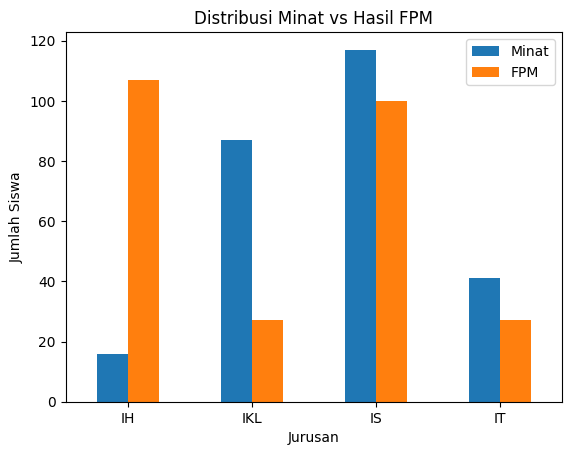

In [200]:
# hitung jumlah
minat_dist = df_all["Minat"].value_counts().sort_index()
fpm_dist = df_all["FPM"].value_counts().sort_index()

# gabungkan
df_dist = pd.DataFrame({
    "Minat": minat_dist,
    "FPM": fpm_dist
}).fillna(0)

display(df_dist)

# plot
df_dist.plot(kind="bar")
plt.title("Distribusi Minat vs Hasil FPM")
plt.xlabel("Jurusan")
plt.ylabel("Jumlah Siswa")
plt.xticks(rotation=0)
plt.show()

,FPM,Sebenarnya
IH,107,24
IKL,27,94
IS,100,90
IT,27,53


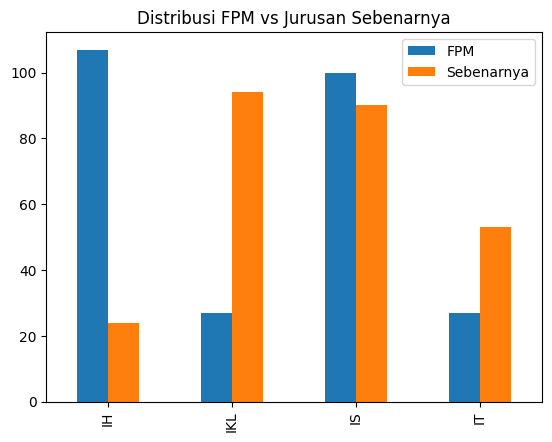

In [201]:
# distribusi fpm vs jurusan sebenarnya
df_dist_real = pd.DataFrame({
    "FPM": df_all["FPM"].value_counts(),
    "Sebenarnya": df_all["Jurusan_Sebenarnya"].value_counts()
}).fillna(0)

display(df_dist_real)

df_dist_real.plot(kind="bar")
plt.title("Distribusi FPM vs Jurusan Sebenarnya")
plt.show()

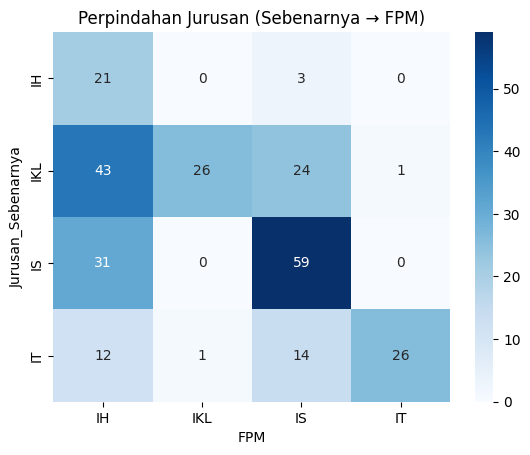

In [202]:
cm = pd.crosstab(df_all["Jurusan_Sebenarnya"], df_all["FPM"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Perpindahan Jurusan (Sebenarnya → FPM)")
plt.show()

# menentukan profil ideal

In [203]:
# from sklearn.model_selection import train_test_split
# import pandas as pd
# import numpy as np

# jurusan_map = {
#     "ilmu kesehatan dan lingkungan": "IKL",
#     "ilmu terapan": "IT",
#     "ilmu sosial": "IS",
#     "ilmu humaniora": "IH",
# }

# def tambah_kode_jurusan(df):
#     df = df.copy()
#     df["Jurusan_Sebenarnya_Kode"] = (
#         df["jurusan_sebenarnya"]
#         .astype(str)
#         .str.strip()
#         .str.lower()
#         .map(jurusan_map)
#     )

#     if df["Jurusan_Sebenarnya_Kode"].isna().any():
#         print(df[df["Jurusan_Sebenarnya_Kode"].isna()][["nama_lengkap", "jurusan_sebenarnya"]])
#         raise ValueError("Ada jurusan_sebenarnya yang tidak cocok dengan jurusan_map.")

#     return df


# def hitung_profil_ideal_dari_train(train_data, metode="median"):
#     rows = []

#     for i in range(len(train_data)):
#         item = train_data.iloc[i].to_dict()

#         # Penting:
#         # proses_fpm_satu_siswa harus menghasilkan DF per jurusan.
#         # Kalau fungsi ini memakai PROFIL_IDEAL untuk ranking, tidak masalah,
#         # karena yang kita ambil hanya detail["df"], bukan ranking akhirnya.
#         hasil = proses_fpm_satu_siswa(item)

#         for jurusan, detail in hasil["hasil_per_jurusan"].items():
#             rows.append({
#                 "Nama": item["nama_lengkap"],
#                 "Jurusan": jurusan,
#                 "DF": detail["df"],
#                 "Jurusan_Sebenarnya_Kode": item["Jurusan_Sebenarnya_Kode"],
#             })

#     df_df = pd.DataFrame(rows)

#     df_real = df_df[
#         df_df["Jurusan"] == df_df["Jurusan_Sebenarnya_Kode"]
#     ].copy()

#     jumlah_per_jurusan = df_real.groupby("Jurusan").size()

#     if metode == "mean":
#         profil_ideal = df_real.groupby("Jurusan")["DF"].mean()
#     elif metode == "median":
#         profil_ideal = df_real.groupby("Jurusan")["DF"].median()
#     else:
#         raise ValueError("metode harus 'mean' atau 'median'.")

#     profil_ideal = profil_ideal.round(3).to_dict()

#     # fallback kalau ada jurusan yang tidak muncul di train
#     for kode in ["IKL", "IT", "IS", "IH"]:
#         if kode not in profil_ideal:
#             profil_ideal[kode] = 2.0

#     return profil_ideal, df_df, df_real, jumlah_per_jurusan

In [204]:
# print("Total data:", len(data))
# print("Train data:", len(train_data))
# print("Test data:", len(test_data))
# print("df_real:", len(df_real))

In [205]:
# data = tambah_kode_jurusan(data)

# train_data, test_data = train_test_split(
#     data,
#     test_size=0.3,
#     random_state=42,
#     stratify=data["Jurusan_Sebenarnya_Kode"]
# )

# profil_ideal, df_semua_df, df_real, jumlah_per_jurusan = hitung_profil_ideal_dari_train(
#     train_data,
#     metode="median"
# )

# profil_ideal

In [206]:
# print(jumlah_per_jurusan)

# print("\nRata-rata DF per jurusan:")
# print(df_real.groupby("Jurusan")["DF"].describe())

In [207]:
# rows = []

# for i in range(len(data)):
#     item = data.iloc[i].to_dict()
#     hasil = proses_fpm_satu_siswa(item)

#     for jurusan, detail in hasil["hasil_per_jurusan"].items():
#         rows.append({
#             "Nama": item["nama_lengkap"],
#             "Jurusan": jurusan,
#             "DF": detail["df"],
#             "Jurusan_Sebenarnya": jurusan[item["jurusan_sebenarnya"]] if False else item["jurusan_sebenarnya"]
#         })

# df_df = pd.DataFrame(rows)

In [208]:
# jurusan_map = {
#     "ilmu kesehatan dan lingkungan": "IKL",
#     "ilmu terapan": "IT",
#     "ilmu sosial": "IS",
#     "ilmu humaniora": "IH",
# }

# df_df["Jurusan_Sebenarnya_Kode"] = (
#     df_df["Jurusan_Sebenarnya"]
#     .str.strip()
#     .str.lower()
#     .map(jurusan_map)
# )

In [209]:
# df_real = df_df[df_df["Jurusan"] == df_df["Jurusan_Sebenarnya_Kode"]]

# profil_ideal_data = (
#     df_real
#     .groupby("Jurusan")["DF"]
#     .mean()
#     .round(3)
# )

# profil_ideal_data

In [210]:
# PROFIL_IDEAL = profil_ideal_data.to_dict()
# PROFIL_IDEAL